# **CS412 Machine Learning - Recitation 9: Probabilities, the Bayes Theorem and Naive Bayes**
========================================

**TA:** Emine Ayşe Sunar  
**Mail**: emine.sunar@sabanciuniv.edu  
**Date:** April 2026

*Original notebook prepared by Ece Tosun (ece.tosun@sabanciuniv.edu), November 2025.*

========================================

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Probability Refresher (Joint, Marginal, Conditional, Sum & Product Rules)

Consider random variables $X$ and $Y$. A joint probability table stores entries such as $P(X = x_i, Y = y_j) = n_{ij}/N$, where $n_{ij}$ is the count of co-occurrences and $N$ is the total sample size.

The **marginal** of $X$ sums across all possible $Y$:

$$
P(X = x_i) = \sum_j P(X = x_i, Y = y_j)
$$

A **conditional probability** isolates a column of the joint table:

$$
P(Y = y_j \mid X = x_i) = \frac{P(X = x_i, Y = y_j)}{P(X = x_i)}
$$

The **sum rule** states:

$$
P(X) = \sum_y P(X, Y = y)
$$

The **product rule** states:

$$
P(X, Y) = P(Y \mid X) P(X) = P(X \mid Y) P(Y)
$$

> How often both things occur together.

To get that, you:
1. Look at how common X is.
2. Then look at how often Y happens among those Xs.

Or vice versa.

These two rules are the only ingredients needed to derive Bayes' theorem and the Bayes optimal classifier.

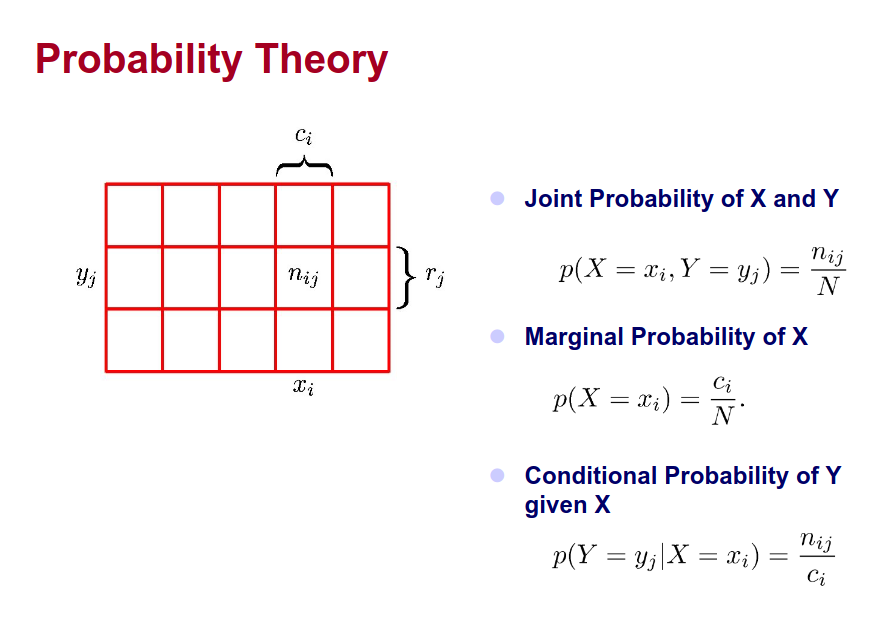

In [28]:
from IPython.display import Image, display
display(Image('/content/Probability_Theorem.png', width=800))

Contingency table:
 Height  Short  Tall
Weight             
Low        12     4
Medium      5     9
High        3     7 

Joint P(X,Y):
 Height  Short   Tall
Weight              
Low     0.300  0.100
Medium  0.125  0.225
High    0.075  0.175 

Marginal P(X):
 Weight
Low       0.40
Medium    0.35
High      0.25
dtype: float64 

Marginal P(Y):
 Height
Short    0.5
Tall     0.5
dtype: float64 

P(Tall | Low) = 0.250


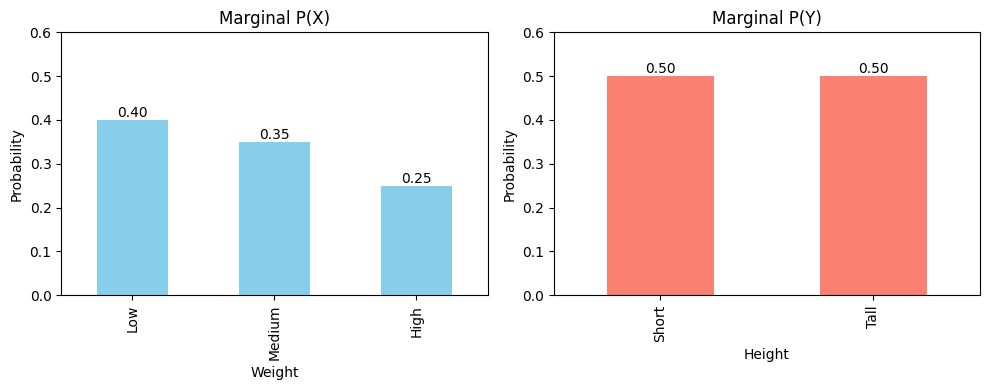

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contingency table
cont = pd.DataFrame(
    {"Short": [12, 5, 3], "Tall": [4, 9, 7]},
    index=pd.Index(["Low", "Medium", "High"], name="Weight")
)
cont.columns.name = "Height"

# This creates a Dataframe:
# - Rows represent Weight categories (Low, Medium, High)
# - Columns represent Height categories (Short, Tall)
# - Each cell value is the count of people with that Weight-Height combination
#
#           Short  Tall
# Low         12     4
# Medium       5     9
# High         3     7
#
# Total: 40 people

# Probabilities
N = cont.values.sum()
P = cont / N                     # joint
Px = P.sum(axis=1)               # marginal X, axis=1 = direction going sideways (across columns) → collapses the columns → you get one value per row
Py = P.sum(axis=0)               # marginal Y, axis=0 = direction going downward (across rows) → collapses the rows → you get one value per column

# Example conditional
cond = P.loc["Low", "Tall"] / Px.loc["Low"]

print("Contingency table:\n", cont, "\n")
print("Joint P(X,Y):\n", P.round(3), "\n")
print("Marginal P(X):\n", Px.round(3), "\n")
print("Marginal P(Y):\n", Py.round(3), "\n")
print(f"P(Tall | Low) = {cond:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
colors = ["skyblue", "salmon"]

for i, (data, title) in enumerate([(Px, "Marginal P(X)"), (Py, "Marginal P(Y)")]):
    data.plot(kind="bar", ax=ax[i], color=colors[i])
    ax[i].set_title(title)
    ax[i].set_ylim(0, 0.6)
    ax[i].set_ylabel("Probability")
    ax[i].bar_label(ax[i].containers[0], fmt="%.2f")

plt.tight_layout()
plt.show()

**Try it:**
- Compute $P(X = \text{Medium})$.
- Compute $P(X = \text{Low}, Y = \text{Tall})$.
- Compute $P(X = \text{Medium} \mid Y = \text{Short})$.

In [30]:
P_medium = 14 / 40
P_low_and_tall = 4 / 40
P_medium_given_short = 5 / 20

print(f"P(X='Medium') = {P_medium:.3f}")
print(f"P(X='Low', Y='Tall') = {P_low_and_tall:.3f}")
print(f"P(X='Medium' | Y='Short') = {P_medium_given_short:.3f}")


P(X='Medium') = 0.350
P(X='Low', Y='Tall') = 0.100
P(X='Medium' | Y='Short') = 0.250


# Bayes' Theorem and Bayesian Decision Theory
Starting from the product rule in both directions we obtain
$$
P(X, Y) = P(X \mid Y) P(Y) = P(Y \mid X) P(X).
$$
Rearranging yields Bayes' theorem:
$$
P(Y \mid X) = \frac{P(X \mid Y) P(Y)}{P(X)}, \quad P(X) = \sum_y P(X \mid Y = y) P(Y = y).
$$
Here $P(Y)$ is the **prior**, $P(X \mid Y)$ the **likelihood**, $P(Y \mid X)$ the **posterior**, and $P(X)$ the **evidence**. The **Bayes optimal classifier** selects the class with the largest posterior probability:
$$
f^*(x) = \arg\max_y P(Y = y \mid X = x) = \arg\max_y P(X = x \mid Y = y) P(Y = y),
$$
where the evidence cancels because it is constant with respect to $y$.

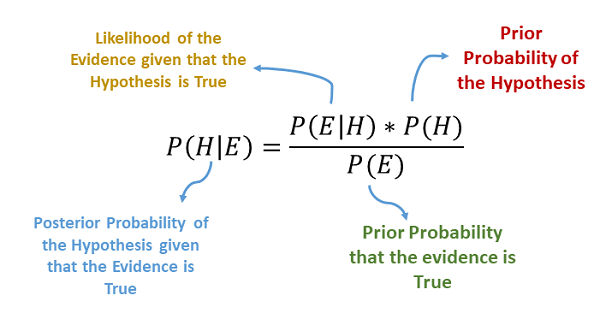

In [31]:
from IPython.display import Image, display
display(Image('/content/Naive_Bayes.png', width=800))

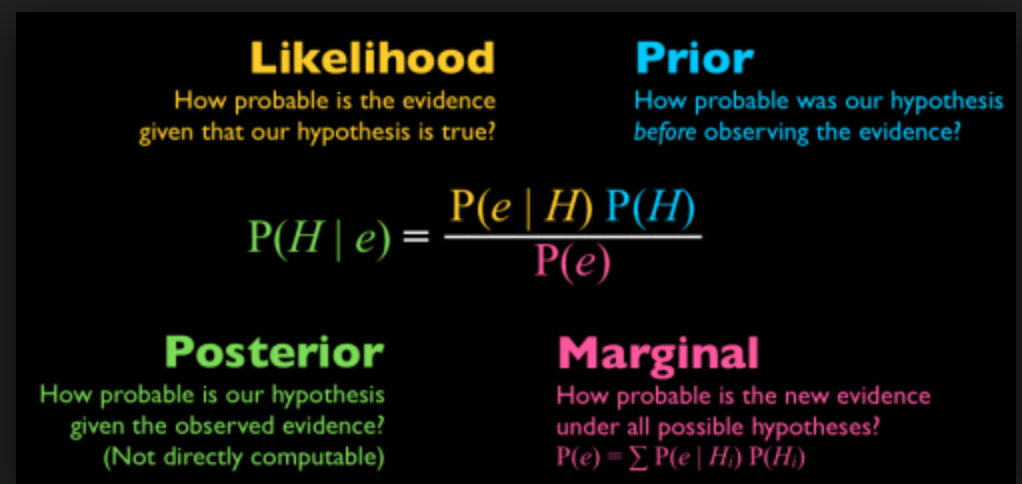

In [32]:
from IPython.display import Image, display
display(Image('/content/Naive_Bayes_2.png', width=800))

# Concrete Example: Bayesian Inference in Medical Testing

Suppose a disease has prevalence $P(\text{Disease}) = 0.01$. A medical test has sensitivity $P(+ \mid \text{Disease}) = 0.95$ and false positive rate $P(+ \mid \neg \text{Disease}) = 0.02$.

The posterior probability of disease after a positive result is:

$$
P(\text{Disease} \mid +) = \frac{0.95 \times 0.01}{0.95 \times 0.01 + 0.02 \times 0.99} \approx 0.324
$$

This demonstrates how a low prior (prevalence) keeps the posterior modest despite an accurate test.

P(+) = 0.0293
P(Disease | +) = 0.324
P(No Disease | +) = 0.676


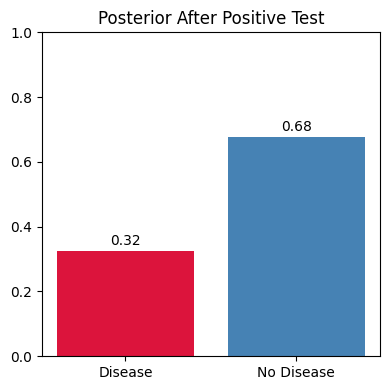

In [33]:
# Given
p_d = 0.01                # prior disease
sens = 0.95               # P(+ | disease)
fp = 0.02                 # P(+ | no disease)

# Compute
p_pos = sens*p_d + fp*(1-p_d)
p_d_pos = sens*p_d / p_pos     # posterior disease
p_nd_pos = 1 - p_d_pos         # posterior no disease

# Print
print(f"P(+) = {p_pos:.4f}")
print(f"P(Disease | +) = {p_d_pos:.3f}")
print(f"P(No Disease | +) = {p_nd_pos:.3f}")

# Plot
vals = [p_d_pos, p_nd_pos]

plt.figure(figsize=(4,4))
plt.bar(["Disease", "No Disease"], vals, color=["crimson", "steelblue"])
plt.title("Posterior After Positive Test")
plt.ylim(0, 1)

for i, v in enumerate(vals):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

# From Bayes Classifier to Naive Bayes (Curse of Dimensionality & Conditional Independence)
To apply the Bayes classifier we need $P(X_1, \dots, X_n \mid Y)$. For discrete features this requires estimating exponentially many parameters: with $n$ binary features we need $2^n$ joint probabilities per class. This is the **curse of dimensionality** -> data requirements explode with dimensionality.
Naive Bayes assumes **conditional independence** of features given the class:
$$
P(X_1, \dots, X_n \mid Y) = \prod_{i=1}^n P(X_i \mid Y).
$$
Conditional independence is rarely exact yet dramatically reduces parameters and often suffices for accurate argmax decisions.

## Intuition Behind Conditional Independence

Two variables are **independent** if knowing one tells you nothing about the other:
$$P(X, Y) = P(X) \cdot P(Y)$$

But **conditional independence** is subtler: two variables can be dependent on their own, yet become independent once you know a third variable Z:
$$P(X \mid Y, Z) = P(X \mid Z)$$

**Classic example: Wet grass, sprinkler, rain**

- X = grass is wet, Y = sprinkler is on, Z = it rained

Without knowing Z: if you see the grass is wet (X), you'd guess the sprinkler is more likely on (Y). So X and Y are **dependent**.

But once you know Z:
- If Z=1 (rained): grass is wet regardless of the sprinkler, knowing Y adds nothing.
- If Z=0 (no rain): wet grass must be the sprinkler, Y is already determined.

In either case, once Z is fixed, X gives no extra information about Y. So X and Y are **conditionally independent given Z**.

**This is exactly the assumption Naive Bayes makes:** features are conditionally independent given the class label. It is rarely exactly true, but it makes the model tractable and works surprisingly well in practice.

## Why Conditional Independence Matters: Parameter Explosion

Without the conditional independence assumption, for **each class** we need to store
the joint probability for **every possible combination** of feature values.

For example, with 3 binary features (X1, X2, X3) and 2 classes (Yes/No):

**Without conditional independence**, 2³ = 8 values per class:

    For class Yes:
    P(X1=0, X2=0, X3=0 | Yes)
    P(X1=0, X2=0, X3=1 | Yes)
    P(X1=0, X2=1, X3=0 | Yes)
    P(X1=0, X2=1, X3=1 | Yes)
    P(X1=1, X2=0, X3=0 | Yes)
    P(X1=1, X2=0, X3=1 | Yes)
    P(X1=1, X2=1, X3=0 | Yes)
    P(X1=1, X2=1, X3=1 | Yes)

    For class No: (same 8 combinations) ...

→ 3 features = **14 parameters total** (7 per class, since probabilities sum to 1).  
30 features = **(2³⁰ - 1) × 2 ≈ 2 billion**!

---

**With conditional independence** — just n values per class:

    For class Yes:        For class No:
    P(X1=1 | Yes)         P(X1=1 | No)
    P(X2=1 | Yes)         P(X2=1 | No)
    P(X3=1 | Yes)         P(X3=1 | No)

→ 3 features = **6 parameters total**. 30 features = just **60**!

---

Instead of storing every combination, we only need each feature independently.
This is what makes Naive Bayes tractable in high dimensions.

   n_features  full_joint  naive_bayes
0           3          14            6
1          10        2046           20
2          20     2097150           40
3          30  2147483646           60


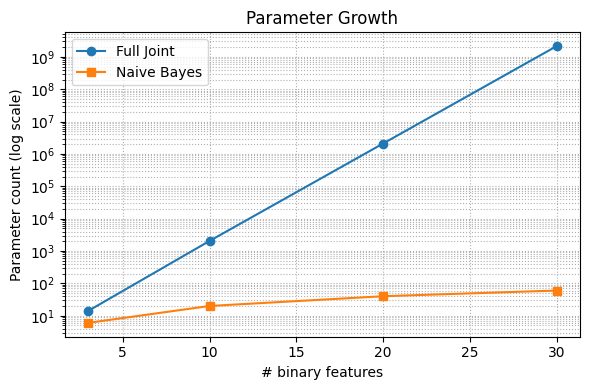

In [34]:
def param_table(n_values=2):
    feats = [3, 10, 20, 30]
    df = pd.DataFrame({
        "n_features": feats,
        "full_joint": [(n_values**f - 1) * 2 for f in feats],
        "naive_bayes": [f * (n_values - 1) * 2 for f in feats]
    })
    return df

df = param_table()
print(df)

plt.figure(figsize=(6, 4))
plt.plot(df.n_features, df.full_joint, "o-", label="Full Joint")
plt.plot(df.n_features, df.naive_bayes, "s-", label="Naive Bayes")
plt.yscale("log")
plt.xlabel("# binary features")
plt.ylabel("Parameter count (log scale)")
plt.title("Parameter Growth")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()



# **Exercise:** For 10 binary features and 3 classes, how many parameters are needed for the full joint model versus Naive Bayes?


## Reminder: Parameter Complexity

**Full Bayes** — parameters per class:
$$k^n - 1$$

**Naïve Bayes** — parameters per class:
$$n(k-1)$$

Where:
- $n$ = number of features
- $k$ = number of possible values each feature can take

## Problem Setup
- **Features**: 10 binary features (X₁, X₂, ..., X₁₀)
- **Classes**: 3 classes (Y ∈ {1, 2, 3})

---

## Full Joint Model

We need to estimate $P(X_1, \ldots, X_{10} \mid Y = c)$ for each class $c$ separately.

Using the formula from the slides: with $k$ values per feature and $n$ features, each class needs $k^n - 1$ free parameters (since probabilities must sum to 1).

- $k = 2$ (binary features), $n = 10$
- Parameters per class: $2^{10} - 1 = 1023$
- 3 classes → **1023 × 3 = 3069 parameters total**

---

## Naive Bayes Model

With conditional independence, we only need each feature separately per class.

### 1. Class prior P(Y):
- 3 classes → **3 - 1 = 2 free parameters**

### 2. Conditional distributions P(Xᵢ = 1 | Y):
- Each binary feature needs only 1 parameter per class (since P(X=0|Y) = 1 - P(X=1|Y))
- 10 features × 3 classes = **30 parameters**

### Total Naive Bayes parameters:
- 2 (priors) + 30 (conditionals) = **32 parameters**

---

## Summary Comparison

| Model | Number of Parameters |
|-------|---------------------|
| Full Joint | 3069 |
| Naive Bayes | 32 |

**Reduction factor**: 3069 / 32 ≈ 96×

The Naive Bayes independence assumption dramatically reduces model complexity!

# Naive Bayes Decision Rule – Math Derivation
The Bayes classifier requires $P(Y = y_k \mid X = x) \propto P(X = x \mid Y = y_k) P(Y = y_k)$. With Naive Bayes conditional independence,
$$
P(X = x \mid Y = y_k) = \prod_{i=1}^n P(X_i = x_i \mid Y = y_k)
$$
Therefore the decision rule is
$$
\hat{y}(x) = \arg\max_{y_k} P(Y = y_k) \prod_{i=1}^n P(X_i = x_i \mid Y = y_k)
$$
Working in log-space avoids underflow:
$$
\log P(Y = y_k \mid X = x) = \log P(Y = y_k) + \sum_{i=1}^n \log P(X_i = x_i \mid Y = y_k)
$$

Log-scores:
  Healthy: -3.170
  Sick: -2.343

Posterior probabilities:
  P(Healthy | x) = 0.304
  P(Sick | x) = 0.696

Prediction: Sick


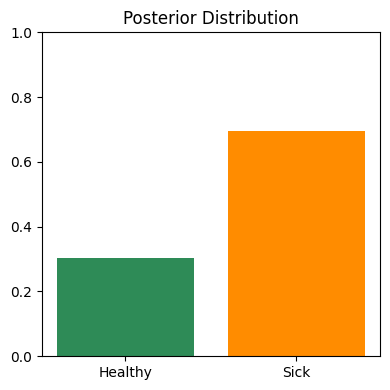

In [35]:
def nb_posterior(x, priors, conds):
    log_scores = {
        c: np.log(priors[c]) +
           sum(np.log(conds[f][v][c]) for f, v in x.items())
        for c in priors
    }

    # stabilize + convert log-scores to probabilities
    max_log = max(log_scores.values())
    probs = {c: np.exp(l - max_log) for c, l in log_scores.items()}
    total = sum(probs.values())
    post = {c: p / total for c, p in probs.items()}
    return post, log_scores


# Example model
priors = {"Healthy": 0.6, "Sick": 0.4}
conds = {
    "Fever": {"Yes": {"Healthy": 0.1, "Sick": 0.8},
              "No": {"Healthy": 0.9, "Sick": 0.2}},
    "Cough": {"Yes": {"Healthy": 0.3, "Sick": 0.7},
              "No": {"Healthy": 0.7, "Sick": 0.3}},
}

x = {"Fever": "Yes", "Cough": "No"}

post, logs = nb_posterior(x, priors, conds)

print("Log-scores:")
for c, l in logs.items():
    print(f"  {c}: {l:.3f}")

print("\nPosterior probabilities:")
for c, p in post.items():
    print(f"  P({c} | x) = {p:.3f}")

print(f"\nPrediction: {max(post, key=post.get)}")

plt.figure(figsize=(4,4))
plt.bar(post.keys(), post.values(), color=["seagreen", "darkorange"])
plt.ylim(0, 1)
plt.title("Posterior Distribution")
plt.tight_layout()
plt.show()

# Categorical Naive Bayes "from scratch" – Play Tennis Example
We will use the classic PlayTennis dataset. Class priors $P(\text{Play})$ and conditionals $P(X_i = v \mid \text{Play})$ are estimated by counting rows. With Laplace smoothing (add-one),
$$
\hat{P}(X_i = v \mid Y = y) = \frac{n_{v,y} + 1}{n_y + K_i},
$$
where $K_i$ is the number of possible values feature $X_i$ can take.


## Manual Calculation — PlayTennis Example

Let's classify the query **x = [Sunny, Cool, High, Strong]** by hand.

**Step 1: Class priors**

$$P(\text{Yes}) = \frac{9}{14} \approx 0.643, \quad P(\text{No}) = \frac{5}{14} \approx 0.357$$

**Step 2: Likelihoods (with Laplace smoothing)**

| Feature | Value | P(v \| Yes) | P(v \| No) |
|---------|-------|------------|-----------|
| Outlook | Sunny | (2+1)/(9+3) = 3/12 | (3+1)/(5+3) = 4/8 |
| Temperature | Cool | (3+1)/(9+3) = 4/12 | (1+1)/(5+3) = 2/8 |
| Humidity | High | (3+1)/(9+2) = 4/11 | (4+1)/(5+2) = 5/7 |
| Wind | Strong | (3+1)/(9+2) = 4/11 | (3+1)/(5+2) = 4/7 |

**Step 3: Compute scores (prior × likelihoods)**

$$\text{Score}(\text{Yes}) = \frac{9}{14} \times \frac{3}{12} \times \frac{4}{12} \times \frac{4}{11} \times \frac{4}{11}$$

$$\text{Score}(\text{No}) = \frac{5}{14} \times \frac{4}{8} \times \frac{2}{8} \times \frac{5}{7} \times \frac{4}{7}$$

**Step 4: Normalize to get posteriors**

$$P(\text{Yes} \mid x) = \frac{\text{Score(Yes)}}{\text{Score(Yes)} + \text{Score(No)}}$$

The class with the higher score wins. Let's verify this with code below.

In [36]:
import numpy as np

# Priors
p_yes = 9/14
p_no = 5/14

# Likelihoods with Laplace smoothing
# P(Outlook=Sunny | Yes), P(Outlook=Sunny | No)
p_sunny_yes = (2+1)/(9+3)
p_sunny_no  = (3+1)/(5+3)

# P(Temp=Cool | Yes), P(Temp=Cool | No)
p_cool_yes = (3+1)/(9+3)
p_cool_no  = (1+1)/(5+3)

# P(Humidity=High | Yes), P(Humidity=High | No)
p_high_yes = (3+1)/(9+2)
p_high_no  = (4+1)/(5+2)

# P(Wind=Strong | Yes), P(Wind=Strong | No)
p_strong_yes = (3+1)/(9+2)
p_strong_no  = (3+1)/(5+2)

# Scores
score_yes = p_yes * p_sunny_yes * p_cool_yes * p_high_yes * p_strong_yes
score_no  = p_no  * p_sunny_no  * p_cool_no  * p_high_no  * p_strong_no

# Normalize
total = score_yes + score_no
post_yes = score_yes / total
post_no  = score_no  / total

print(f"Score(Yes) = {score_yes:.6f}")
print(f"Score(No)  = {score_no:.6f}")
print(f"\nP(Yes | x) = {post_yes:.3f}")
print(f"P(No  | x) = {post_no:.3f}")
print(f"\nPrediction: {'Yes' if post_yes > post_no else 'No'}")

Score(Yes) = 0.007084
Score(No)  = 0.018222

P(Yes | x) = 0.280
P(No  | x) = 0.720

Prediction: No


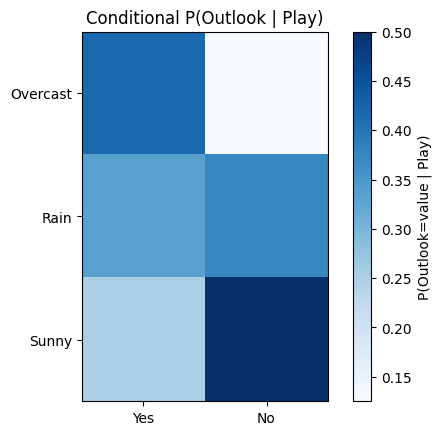

Posterior probabilities:
  P(Yes | x_query) = 0.280
  P(No | x_query) = 0.720

Prediction: No


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Dataset ---
df = pd.DataFrame([
    {"Outlook":"Sunny","Temperature":"Hot","Humidity":"High","Wind":"Weak","Play":"No"},
    {"Outlook":"Sunny","Temperature":"Hot","Humidity":"High","Wind":"Strong","Play":"No"},
    {"Outlook":"Overcast","Temperature":"Hot","Humidity":"High","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Rain","Temperature":"Mild","Humidity":"High","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Rain","Temperature":"Cool","Humidity":"Normal","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Rain","Temperature":"Cool","Humidity":"Normal","Wind":"Strong","Play":"No"},
    {"Outlook":"Overcast","Temperature":"Cool","Humidity":"Normal","Wind":"Strong","Play":"Yes"},
    {"Outlook":"Sunny","Temperature":"Mild","Humidity":"High","Wind":"Weak","Play":"No"},
    {"Outlook":"Sunny","Temperature":"Cool","Humidity":"Normal","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Rain","Temperature":"Mild","Humidity":"Normal","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Sunny","Temperature":"Mild","Humidity":"Normal","Wind":"Strong","Play":"Yes"},
    {"Outlook":"Overcast","Temperature":"Mild","Humidity":"High","Wind":"Strong","Play":"Yes"},
    {"Outlook":"Overcast","Temperature":"Hot","Humidity":"Normal","Wind":"Weak","Play":"Yes"},
    {"Outlook":"Rain","Temperature":"Mild","Humidity":"High","Wind":"Strong","Play":"No"},
])

features = ["Outlook","Temperature","Humidity","Wind"]
target = "Play"

# --- Fit NB ---
def fit_nb(df, features, target):
    class_counts = df[target].value_counts()
    priors = (class_counts / len(df)).to_dict()
    cond = {f:{} for f in features}

    for f in features:
        tab = df.groupby([f, target]).size().unstack(fill_value=0)
        K = len(tab.index)
        for v in tab.index:
            cond[f][v] = {
                c: (tab.loc[v,c] + 1) / (class_counts[c] + K)
                for c in class_counts.index
            }
    return priors, cond

priors, cond = fit_nb(df, features, target)

# --- Show Outlook conditional matrix ---
outlook_df = pd.DataFrame(cond["Outlook"]).T
plt.imshow(outlook_df, cmap="Blues")
plt.xticks(range(len(outlook_df.columns)), outlook_df.columns)
plt.yticks(range(len(outlook_df.index)), outlook_df.index)
plt.colorbar(label="P(Outlook=value | Play)")
plt.title("Conditional P(Outlook | Play)")
plt.show()

# --- Prediction ---
def predict(x, priors, cond):
    scores = {}
    for c,p in priors.items():
        s = p
        for f,v in x.items():
            s *= cond[f][v][c]
        scores[c] = s
    total = sum(scores.values())
    post = {c: s/total for c,s in scores.items()}
    return post

x_query = {"Outlook":"Sunny","Temperature":"Cool","Humidity":"High","Wind":"Strong"}
post = predict(x_query, priors, cond)

print("Posterior probabilities:")
for c,p in post.items():
    print(f"  P({c} | x_query) = {p:.3f}")

print("\nPrediction:", max(post, key=post.get))

## The Zero Probability Problem — Why Laplace Smoothing Matters

What happens if a feature value never appears in training for a given class?

For example, in PlayTennis, **Outlook=Overcast never appears when Play=No** (0 out of 5 examples).

Without smoothing: $P(\text{Overcast} \mid \text{No}) = 0/5 = 0$

This single zero **kills the entire score** for class No, no matter how strong the other evidence is:

$$\text{Score}(\text{No}) = P(\text{No}) \times 0 \times \ldots = 0$$

Laplace smoothing fixes this by adding a virtual count of 1 to every feature value:
$$\hat{P}(X_i = v \mid Y = y) = \frac{n_{v,y} + 1}{n_y + K}$$

where $K$ is the number of possible values for feature $X_i$.

In [38]:
# Query that contains Outlook=Overcast (never seen in Play=No training data!)
# Without Laplace smoothing

p_no = 5/14

# Likelihoods WITHOUT smoothing (raw counts)
p_overcast_no = 0/5   # 0 times Overcast appeared when Play=No
p_cool_no     = 1/5
p_high_no     = 4/5
p_strong_no   = 3/5

score_no_raw = p_no * p_overcast_no * p_cool_no * p_high_no * p_strong_no
print(f"WITHOUT Laplace smoothing:")
print(f"  P(Overcast | No) = {p_overcast_no}")
print(f"  Score(No) = {score_no_raw}  ← zero kills everything!")

print()

# WITH Laplace smoothing
p_overcast_no_smooth = (0+1)/(5+3)  # K=3 outlook values
p_cool_no_smooth     = (1+1)/(5+3)
p_high_no_smooth     = (4+1)/(5+2)  # K=2 humidity values
p_strong_no_smooth   = (3+1)/(5+2)  # K=2 wind values

score_no_smooth = p_no * p_overcast_no_smooth * p_cool_no_smooth * p_high_no_smooth * p_strong_no_smooth
print(f"WITH Laplace smoothing:")
print(f"  P(Overcast | No) = {p_overcast_no_smooth:.3f}")
print(f"  Score(No) = {score_no_smooth:.6f}  ← survives!")

WITHOUT Laplace smoothing:
  P(Overcast | No) = 0.0
  Score(No) = 0.0  ← zero kills everything!

WITH Laplace smoothing:
  P(Overcast | No) = 0.125
  Score(No) = 0.004555  ← survives!


P(Outlook | Play=No) WITHOUT smoothing:
  Sunny: 0.600
  Overcast: 0.000
  Rain: 0.400

P(Outlook | Play=No) WITH Laplace smoothing:
  Sunny: 0.500
  Overcast: 0.125
  Rain: 0.375

--- Effect on classification ---
Query contains Outlook=Overcast
Without smoothing: P(Overcast|No) = 0.000  → entire Score(No) = 0!
With smoothing:    P(Overcast|No) = 0.125 → Score(No) survives


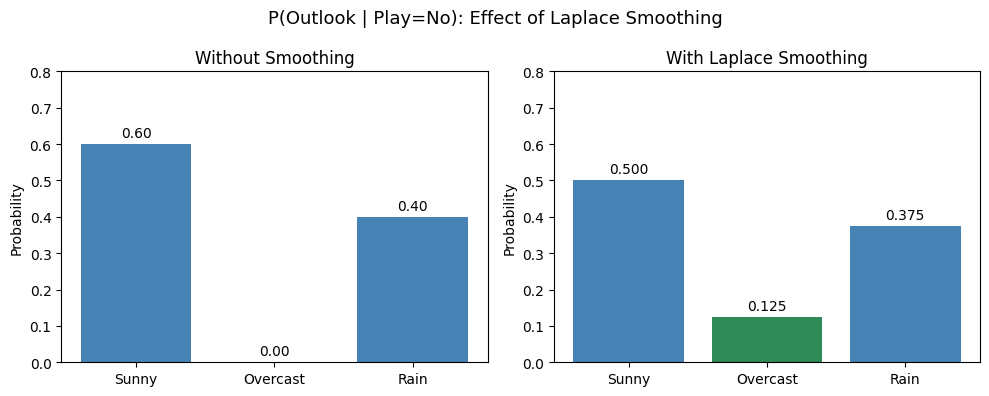

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Outlook counts for Play=No: Sunny=3, Overcast=0, Rain=2, total=5
counts_no = {"Sunny": 3, "Overcast": 0, "Rain": 2}
n_no = 5
K = 3  # 3 possible outlook values

# Without smoothing
without = {v: c/n_no for v, c in counts_no.items()}

# With Laplace smoothing
with_lap = {v: (c+1)/(n_no+K) for v, c in counts_no.items()}

print("P(Outlook | Play=No) WITHOUT smoothing:")
for v, p in without.items():
    print(f"  {v}: {p:.3f}")

print("\nP(Outlook | Play=No) WITH Laplace smoothing:")
for v, p in with_lap.items():
    print(f"  {v}: {p:.3f}")

# Show what happens to the full score without smoothing
query = {"Outlook": "Overcast", "Temperature": "Cool", "Humidity": "High", "Wind": "Strong"}
print("\n--- Effect on classification ---")
print("Query contains Outlook=Overcast")
print(f"Without smoothing: P(Overcast|No) = {without['Overcast']:.3f}  → entire Score(No) = 0!")
print(f"With smoothing:    P(Overcast|No) = {with_lap['Overcast']:.3f} → Score(No) survives")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
values = list(counts_no.keys())

axes[0].bar(values, list(without.values()), color=["steelblue","crimson","steelblue"])
axes[0].set_title("Without Smoothing")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 0.8)
for i, v in enumerate(without.values()):
    axes[0].text(i, v+0.02, f"{v:.2f}", ha="center")

axes[1].bar(values, list(with_lap.values()), color=["steelblue","seagreen","steelblue"])
axes[1].set_title("With Laplace Smoothing")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 0.8)
for i, v in enumerate(with_lap.values()):
    axes[1].text(i, v+0.02, f"{v:.3f}", ha="center")

plt.suptitle("P(Outlook | Play=No): Effect of Laplace Smoothing", fontsize=13)
plt.tight_layout()
plt.show()